# Matrices As Linear Transformations

*Course notes for **Math for Machine Learning**, C1 · W3 · L2 · V01 — "Matrices As Linear Transformations" (DeepLearning.AI).*

So far a matrix has represented a **system of linear equations**. This lesson introduces a second, equally powerful view: a matrix is a **linear transformation** — a structured way to send every point of the plane to another point. We cover:

- What a linear transformation does (multiply each point, as a column vector, by the matrix).
- How the **unit square (a basis)** maps to a **parallelogram**, and why the matrix **columns** are exactly the images of the basis vectors.
- Why a transformation is really a **change of coordinates**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. A matrix sends points to points

Take the $2 \times 2$ matrix

$$ M = \begin{pmatrix} 3 & 1 \\ 1 & 2 \end{pmatrix}. $$

It defines a transformation from the plane (axes $a, b$) to the plane: every point has two coordinates that form a **column vector**; multiply that vector by $M$ and the result is where the point **lands**.

Let's map the four corners of the **unit square**:

| point | $M \cdot \text{point}$ | lands at |
|---|---|---|
| $(0,0)$ | | $(0,0)$ |
| $(1,0)$ | | $(3,1)$ |
| $(0,1)$ | | $(1,2)$ |
| $(1,1)$ | | $(4,3)$ |

Note $(0,0) \to (0,0)$: a linear transformation **always sends the origin to the origin**.

In [2]:
M = np.array([[3, 1],
              [1, 2]])

for p in [(0, 0), (1, 0), (0, 1), (1, 1)]:
    print(f'{p} -> {M @ np.array(p)}')

(0, 0) -> [0 0]
(1, 0) -> [3 1]
(0, 1) -> [1 2]
(1, 1) -> [4 3]


## 2. The columns are the images of the basis vectors

Look closely at two of those mappings:

$$ M\begin{pmatrix}1\\0\end{pmatrix} = \begin{pmatrix}3\\1\end{pmatrix} \;(\text{1st column}), \qquad M\begin{pmatrix}0\\1\end{pmatrix} = \begin{pmatrix}1\\2\end{pmatrix} \;(\text{2nd column}). $$

The images of the standard basis vectors $(1,0)$ and $(0,1)$ are exactly the **columns of $M$**. That's why knowing where the unit square goes **defines the entire transformation** — the unit square is a **basis**, and its image is a **parallelogram** spanned by the two columns.

In [3]:
e1 = np.array([1, 0])
e2 = np.array([0, 1])
print('M e1 =', M @ e1, ' = first  column of M')
print('M e2 =', M @ e2, ' = second column of M')

M e1 = [3 1]  = first  column of M
M e2 = [1 2]  = second column of M


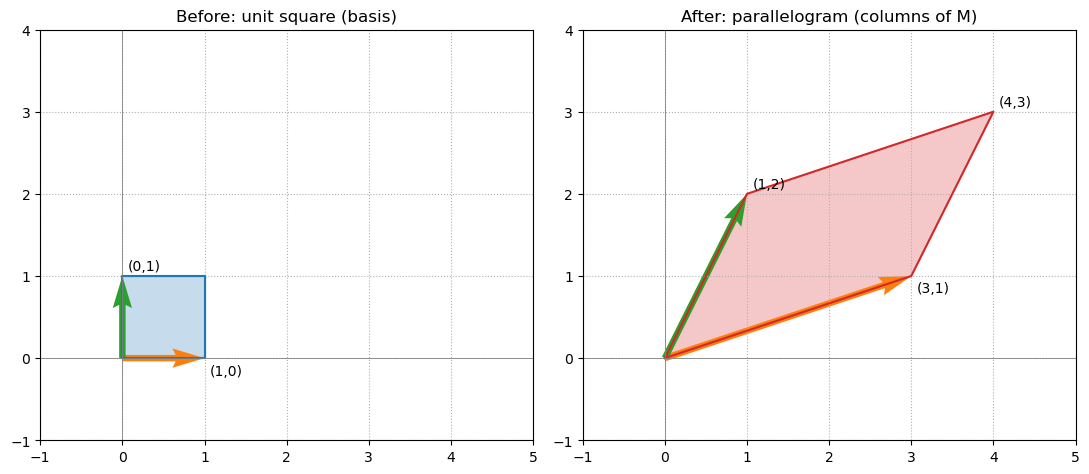

In [4]:
# Visualize: unit square (basis) -> parallelogram
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T   # 2 x 5, closed loop
image  = M @ square

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
opts = dict(angles='xy', scale_units='xy', scale=1, width=0.013)

# left: original basis / unit square
ax = axes[0]
ax.fill(square[0], square[1], color='C0', alpha=0.25)
ax.plot(square[0], square[1], color='C0')
ax.quiver(0, 0, *e1, color='C1', **opts)
ax.quiver(0, 0, *e2, color='C2', **opts)
ax.annotate('(1,0)', e1, textcoords='offset points', xytext=(4, -12))
ax.annotate('(0,1)', e2, textcoords='offset points', xytext=(4, 4))
ax.set_title('Before: unit square (basis)')
ax.set_xlim(-1, 5); ax.set_ylim(-1, 4)

# right: image parallelogram
ax = axes[1]
ax.fill(image[0], image[1], color='C3', alpha=0.25)
ax.plot(image[0], image[1], color='C3')
ax.quiver(0, 0, *(M @ e1), color='C1', **opts)
ax.quiver(0, 0, *(M @ e2), color='C2', **opts)
ax.annotate('(3,1)', M @ e1, textcoords='offset points', xytext=(4, -12))
ax.annotate('(1,2)', M @ e2, textcoords='offset points', xytext=(4, 4))
ax.annotate('(4,3)', M @ np.array([1, 1]), textcoords='offset points', xytext=(4, 4))
ax.set_title('After: parallelogram (columns of M)')
ax.set_xlim(-1, 5); ax.set_ylim(-1, 4)

for ax in axes:
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

## 3. A transformation is a change of coordinates

Because the basis **tiles (tessellates) the whole plane**, and its image parallelogram tiles the plane too, the transformation is simply a **change of coordinates**: to find where any point goes, take the same "steps" but in the **new** grid.

For the point $(-2, 3)$: on the left you reach it from the origin by walking **2 blocks left and 3 blocks up** along the original axes. In the transformed picture, walk 2 blocks left and 3 blocks up along the **new** axes (the columns of $M$):

$$ M \begin{pmatrix} -2 \\ 3 \end{pmatrix} = \begin{pmatrix} 3(-2)+1(3) \\ 1(-2)+2(3) \end{pmatrix} = \begin{pmatrix} -3 \\ 4 \end{pmatrix}. $$

Equivalently, $M(-2,3) = -2\,(\text{col}_1) + 3\,(\text{col}_2)$ — the output is a **linear combination of the columns** with the point's coordinates as weights.

In [5]:
p = np.array([-2, 3])
print('M @ (-2, 3) =', M @ p)

# same thing as a linear combination of the columns
combo = p[0] * M[:, 0] + p[1] * M[:, 1]
print('-2*col1 + 3*col2 =', combo)

M @ (-2, 3) = [-3  4]
-2*col1 + 3*col2 = [-3  4]


## Summary

- A matrix has two faces: a **system of equations** and a **linear transformation** that sends each point $x$ to $Mx$.
- A linear transformation always fixes the **origin** ($M\,0 = 0$).
- The **columns of $M$** are the images of the standard basis vectors $(1,0)$ and $(0,1)$, so the **unit square (basis)** maps to the **parallelogram** they span — and that fully determines the transformation.
- Since a basis tiles the whole plane, the transformation is a **change of coordinates**: $Mx$ is the **linear combination of the columns** weighted by $x$'s coordinates.